In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

We load clean data

In [2]:
try:
    df = pd.read_csv("../Data/Processed/clean_data_encoded.csv")
except FileNotFoundError:
    df = pd.read_csv("https://raw.githubusercontent.com/selomrani/EduPredict/refs/heads/main/Data/Processed/clean_data_encoded.csv")

X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

Split into train (80%) and test (20%)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train the SVR model and predict

In [4]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Evaluate with RMSE, MAE and R²

In [5]:
scores = cross_val_score(model, X_train, y_train, cv=5,
                         scoring="neg_root_mean_squared_error")
print("5-fold CV RMSE:", round(-scores.mean(), 2),
      "(+/-", round(scores.std(), 2), ")")

5-fold CV RMSE: 0.59 (+/- 0.01 )


In [6]:
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print("MAE :", round(mean_absolute_error(y_test, y_pred), 2))
print("R²  :", round(r2_score(y_test, y_pred), 4))

RMSE: 0.54
MAE : 0.4
R²  : 0.9718


In [7]:
param_grid = {"svr__C": [0.1, 1, 10, 100],
              "svr__kernel": ["rbf", "linear"],
              "svr__epsilon": [0.01, 0.1, 1.0],
              "svr__gamma": ["scale", 0.1, 0.01]}

grid = GridSearchCV(model, param_grid, cv=3, scoring="r2")
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svr', SVR())]),
             param_grid={'svr__C': [0.1, 1, 10, 100],
                         'svr__epsilon': [0.01, 0.1, 1.0],
                         'svr__gamma': ['scale', 0.1, 0.01],
                         'svr__kernel': ['rbf', 'linear']},
             scoring='r2')

In [8]:
best = grid.best_estimator_
y_pred_best = best.predict(X_test)

print("best params:", grid.best_params_)
print("best CV R2  :", round(grid.best_score_, 4))
print("After opt - RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_best)), 2),
      "| MAE:", round(mean_absolute_error(y_test, y_pred_best), 2),
      "| R2:", round(r2_score(y_test, y_pred_best), 4))

best params: {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}
best CV R2  : 0.9897
After opt - RMSE: 0.33 | MAE: 0.27 | R2: 0.9897


Plot actual vs predicted

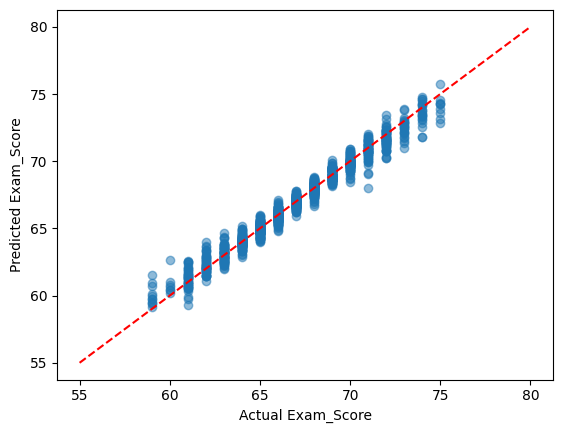

In [9]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([55, 80], [55, 80], "r--")
plt.xlabel("Actual Exam_Score")
plt.ylabel("Predicted Exam_Score")
plt.show()